<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install numpy matplotlib scikit-learn tensorflow

In [ ]:
import os
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [ ]:
dataset_path = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/channel_data"

In [ ]:
import os
import h5py
import numpy as np

def load_channels(dataset_path):

    X = []
    y = []
    env = []

    files = os.listdir(dataset_path)

    for file in files:

        if not file.endswith(".hdf5"):
            continue

        file_path = os.path.join(dataset_path, file)

        # assign labels
        if "NLOS" in file:
            label = 1
        else:
            label = 0

        environment = file.replace(".hdf5","")

        with h5py.File(file_path, 'r') as f:

            # check dataset keys
            key = list(f.keys())[0]
            data = f[key][:]

            # expected shape
            # (antennas, frames, subcarriers)

            antennas, frames, subcarriers = data.shape

            for i in range(frames):

                sample = data[:, i, :]

                X.append(sample)
                y.append(label)
                env.append(environment)

    return np.array(X), np.array(y), np.array(env)

In [ ]:
X, y, env = load_channels(dataset_path)

print(X.shape)
print(y.shape)
print("env shape:", env.shape)

(53016, 64, 52)
(53016,)
env shape: (53016,)


In [ ]:
X = np.abs(X)

In [ ]:
X = (X - X.mean()) / X.std()

In [ ]:
X = X[..., np.newaxis]

print(X.shape)

(53016, 64, 52, 1)


In [ ]:
test_envs = [
    "processed_channe14_LOS_cluster4",
    "processed_channe14_NLOS_cluster5"
]

train_idx = ~np.isin(env, test_envs)
test_idx = np.isin(env, test_envs)

X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

Testing and Training sets

In [ ]:
print("Train environments:", np.unique(env[train_idx]))
print("Test environment:", np.unique(env[test_idx]))

Train environments: ['processed_channe14_LOS_cluster1' 'processed_channe14_LOS_cluster2'
 'processed_channe14_LOS_cluster3' 'processed_channe14_NLOS_cluster1'
 'processed_channe14_NLOS_cluster2' 'processed_channe14_NLOS_cluster3'
 'processed_channe14_NLOS_cluster4']
Test environment: ['processed_channe14_LOS_cluster4' 'processed_channe14_NLOS_cluster5']


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

CNN

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(64,52,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (33003, 64, 52, 1)
Validation shape: (8251, 64, 52, 1)
Test shape: (11762, 64, 52, 1)


In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val,y_val),

    epochs=30,
    batch_size=64,

    callbacks=[early_stop]
)

Epoch 1/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 278s 531ms/step - accuracy: 0.9954 - loss: 0.0171 - val_accuracy: 0.9999 - val_loss: 3.8394e-04
Epoch 2/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 313s 515ms/step - accuracy: 1.0000 - loss: 1.0969e-05 - val_accuracy: 1.0000 - val_loss: 1.8762e-09
Epoch 3/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 274s 532ms/step - accuracy: 1.0000 - loss: 1.7356e-06 - val_accuracy: 1.0000 - val_loss: 5.3925e-10
Epoch 4/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 267s 517ms/step - accuracy: 0.9988 - loss: 0.0270 - val_accuracy: 0.9131 - val_loss: 5.7089
Epoch 5/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 335s 542ms/step - accuracy: 0.9991 - loss: 0.0230 - val_accuracy: 1.0000 - val_loss: 2.7710e-34
Epoch 6/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 266s 515ms/step - accuracy: 0.9998 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 8.4637e-15
Epoch 7/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 320s 512ms/step - accuracy: 1.0000 - loss: 1.4668e-06 - val_accuracy: 1.0000 - val_loss: 4.4855e-22
Epoch 8/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
test_loss, test_acc = model.evaluate(X_test,y_test)

print("Test Accuracy:",test_acc)

368/368 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 1.0


In [ ]:
pred = model.predict(X_test)
pred = (pred > 0.5).astype(int)

print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

368/368 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step
[[7900    0]
 [   0 3862]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7900
           1       1.00      1.00      1.00      3862

    accuracy                           1.00     11762
   macro avg       1.00      1.00      1.00     11762
weighted avg       1.00      1.00      1.00     11762



In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, pred)

print("F1 Score:", f1)

F1 Score: 1.0


In [ ]:
from sklearn.metrics import f1_score

f1_per_class = f1_score(y_test, pred, average=None)

print("F1 Score LOS:", f1_per_class[0])
print("F1 Score NLOS:", f1_per_class[1])

F1 Score LOS: 1.0
F1 Score NLOS: 1.0


In [ ]:
power = np.mean(np.abs(X_norm), axis=(1,2,3))

print("Mean power:", np.mean(power))
print("Std power:", np.std(power))

Mean power: 0.014348340600223112
Std power: 0.000520117213220963


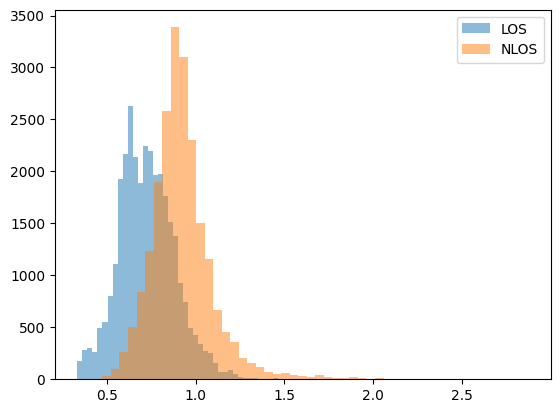

In [ ]:
power = np.mean(np.abs(X), axis=(1,2))

import matplotlib.pyplot as plt
plt.hist(power[y==0], bins=50, alpha=0.5, label="LOS")
plt.hist(power[y==1], bins=50, alpha=0.5, label="NLOS")
plt.legend()

In [ ]:
print(np.unique(y, return_counts=True))

(array([0, 1]), array([31708, 21308]))


Checking model performance in only power feature

In [ ]:
power = np.mean(np.abs(X_test), axis=(1,2))

threshold = np.mean(power)

pred_power = (power > threshold).astype(int)

from sklearn.metrics import accuracy_score
print("Power-only accuracy:", accuracy_score(y_test, pred_power))

Power-only accuracy: 0.7179901377316783


Checking model accuracy in Logistic Regression to verify no data leakage

In [ ]:
from sklearn.linear_model import LogisticRegression

X_flat = X.reshape(X.shape[0], -1)

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_flat[train_idx], y[train_idx])

print("Logistic regression accuracy:",
      model_lr.score(X_flat[test_idx], y[test_idx]))

Logistic regression accuracy: 0.32383948308110866


In [ ]:
import matplotlib.pyplot as plt

# find first Conv2D layer automatically
for layer in model.layers:
    if "conv" in layer.name.lower():
        first_conv = layer
        break

filters = first_conv.get_weights()[0]

print("Filter shape:", filters.shape)

Filter shape: (3, 3, 1, 32)


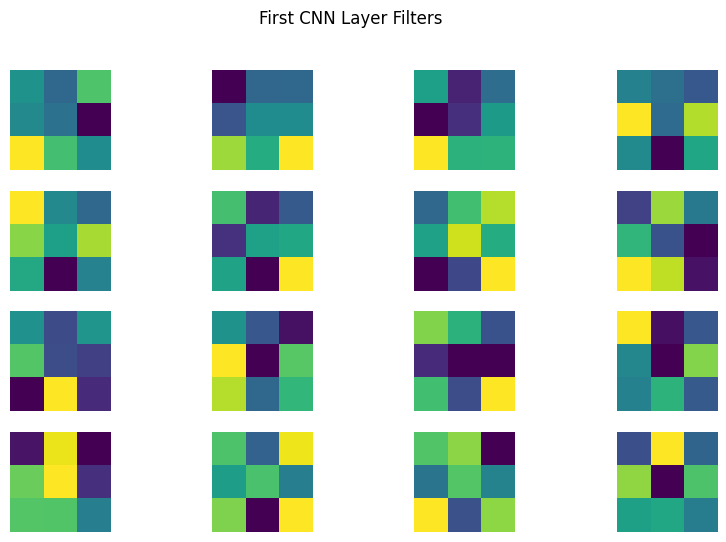

In [ ]:
plt.figure(figsize=(10,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(filters[:,:,0,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("First CNN Layer Filters")
plt.show()

In [ ]:
model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[0.]], dtype=float32)

In [ ]:
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers[:4]]

activation_model = Model(
    inputs=model.inputs,
    outputs=layer_outputs
)

In [ ]:
sample = X_test[0:1]

activations = activation_model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


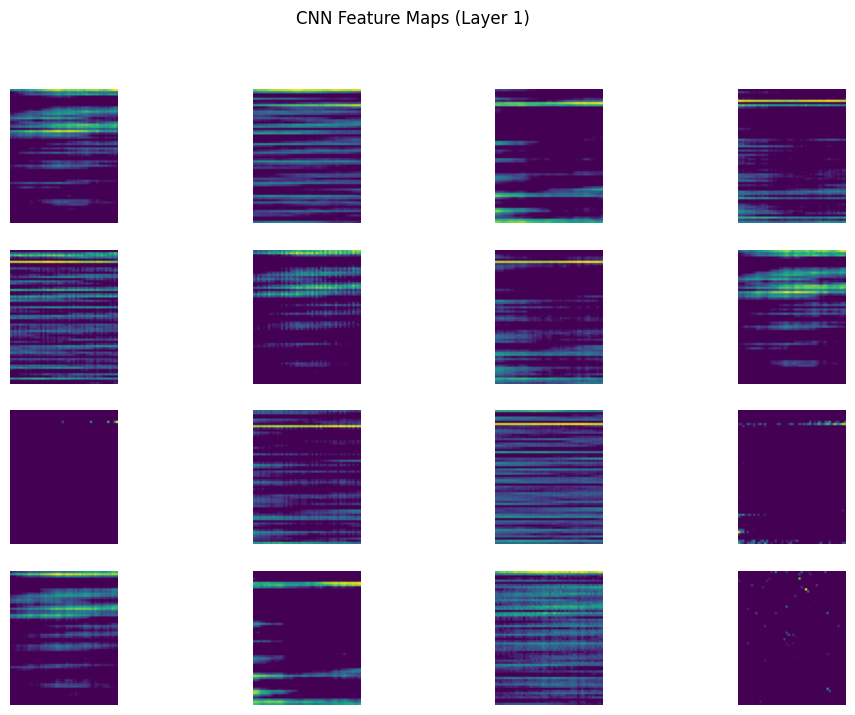

In [ ]:
feature_maps = activations[1]

plt.figure(figsize=(12,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("CNN Feature Maps (Layer 1)")
plt.show()

In [ ]:
#X_norm = X / np.linalg.norm(X, axis=(1,2), keepdims=True)

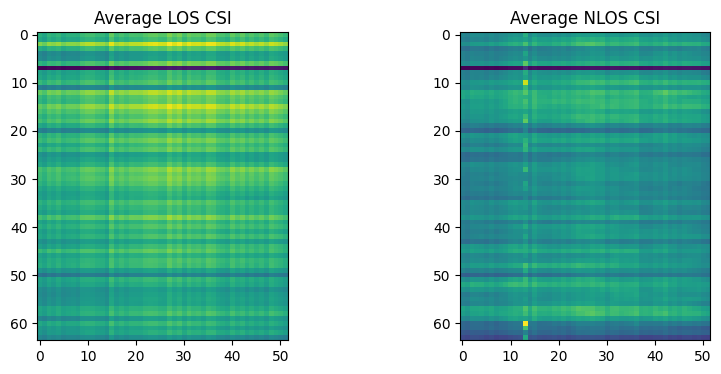

In [ ]:
los_mean = np.mean(X[y==0], axis=0)
nlos_mean = np.mean(X[y==1], axis=0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(los_mean[:,:,0])
plt.title("Average LOS CSI")

plt.subplot(1,2,2)
plt.imshow(nlos_mean[:,:,0])
plt.title("Average NLOS CSI")

plt.show()